# IMDB Movie Scraping and regression

In this notebook scrapes data and runs a regression

### Import Libraries

In [2]:
!pip install IMDbPY

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.2/297.2 kB 18.6 MB/s eta 0:00:00


In [3]:
from imdb import Cinemagoer
import statsmodels.api as sm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

### Create 3 lists and combine

we create 3 sperate lists

In [5]:
highly_rated_ids = ['0111161', '0071562', '0468569', '6763252', '0108052', '0167260', '0110912', '0137523', '0120737',
                    '0109830', '0060196', '0120815', '0245429', '0120689',  '0110357', '0099685','2891174']

medium_rated_ids = ['0120735', '0103064', '0073486', '0047478', '0816692','1591095', '0038650', '0118799', '0088763', '0120812', '0076759',
                    '0054215', '0034583', '0110413', '2649554', '0120338', '0109830', '0102926', '0169547', '0112573', '1840309','2910814']

low_rated_ids = ['5463162','1196141','5033998' ,'0071913', '0235198', '5691670', '3099498', '0106332', '0212826', '1333635','1976009',
                 '0938283', '0415496', '1571234', '0102677', '1232200', '1564367', '1588173', '0873886']

all_movies = highly_rated_ids + medium_rated_ids + low_rated_ids


## Scraping

In [6]:
# Create an instance of the Cinemagoer class
ia = Cinemagoer()

# Create an empty list to store movie details
movies_data = []

# Iterate over each movie ID

countno = 1

for movie_id in all_movies:
    # Get movie details using IMDbPY
    movie = ia.get_movie(movie_id)

    # Extract information
    title = movie['title']
    release_year = movie.get('year', 'N/A')
    genres = ', '.join(movie.get('genres', []))
    rating = movie.get('rating', 'N/A')
    votes = movie['votes']
    runtime = movie['runtime'][0]

    # Append movie details to the list
    movies_data.append({
        'Title': title,
        'Release Year': release_year,
        'Genres': genres,
        'Rating': rating,
        'votes': votes,
        'runtime':runtime
    })
    print(str(countno) +" : " + movie_id)
    countno = countno+1



1 : 0111161
2 : 0071562
3 : 0468569
4 : 6763252
5 : 0108052
6 : 0167260
7 : 0110912
8 : 0137523
9 : 0120737
10 : 0109830
11 : 0060196
12 : 0120815
13 : 0245429
14 : 0120689
15 : 0110357
16 : 0099685
17 : 2891174
18 : 0120735
19 : 0103064
20 : 0073486
21 : 0047478
22 : 0816692
23 : 1591095
24 : 0038650
25 : 0118799
26 : 0088763
27 : 0120812
28 : 0076759
29 : 0054215
30 : 0034583
31 : 0110413
32 : 2649554
33 : 0120338
34 : 0109830
35 : 0102926
36 : 0169547
37 : 0112573
38 : 1840309
39 : 2910814
40 : 5463162
41 : 1196141
42 : 5033998
43 : 0071913
44 : 0235198
45 : 5691670
46 : 3099498
47 : 0106332
48 : 0212826
49 : 1333635
50 : 1976009
51 : 0938283
52 : 0415496
53 : 1571234
54 : 0102677
55 : 1232200
56 : 1564367
57 : 1588173
58 : 0873886


In [7]:
movies_df = pd.DataFrame(movies_data)

In [8]:
movies_df.to_csv('movie_data.csv', index=False)

In [9]:
movies_df = pd.read_csv('movie_data.csv')

In [10]:
movies_df.head(10)

,Title,Release Year,Genres,Rating,votes,runtime
0,The Shawshank Redemption,1994,Drama,9.3,3038384,142
1,The Godfather Part II,1974,"Crime, Drama",9.0,1426921,202
2,The Dark Knight,2008,"Action, Crime, Drama, Thriller",9.0,3015148,152
3,The Captain,2017,"Drama, History, Thriller, War",7.3,22955,118
4,Schindler's List,1993,"Biography, Drama, History",9.0,1519881,195
5,The Lord of the Rings: The Return of the King,2003,"Adventure, Drama, Fantasy",9.0,2074466,201
6,Pulp Fiction,1994,"Crime, Drama",8.9,2330943,154
7,Fight Club,1999,"Crime, Drama, Thriller",8.8,2459675,139
8,The Lord of the Rings: The Fellowship of the Ring,2001,"Adventure, Drama, Fantasy",8.9,2104300,178
9,Forrest Gump,1994,"Drama, Romance",8.8,2374870,142


In [11]:
movies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58 entries, 0 to 57
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         58 non-null     object 
 1   Release Year  58 non-null     int64  
 2   Genres        58 non-null     object 
 3   Rating        58 non-null     float64
 4   votes         58 non-null     int64  
 5   runtime       58 non-null     int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 2.8+ KB


In [12]:
movies_df['runtime'] = movies_df['runtime'].apply(float)

In [13]:
movies_df.to_csv('movie_data.csv', index=False)# this is to save the dataset

See the number of records in the movie_data.csv

In [14]:
# prompt: See the number of records in the movie_data.csv

import pandas as pd

movies_df = pd.read_csv('movie_data.csv')
print(len(movies_df))


58


In [15]:
movies_df.describe()

,Release Year,Rating,votes,runtime
count,58.000000,58.000000,5.800000e+01,58.000000
mean,1997.017241,7.672414,8.892220e+05,129.568966
std,17.859580,1.264466,8.654167e+05,34.486261
min,1942.000000,4.000000,3.400000e+01,54.000000
25%,1993.000000,6.800000,8.346275e+04,109.250000
50%,1998.500000,8.300000,6.729895e+05,118.500000
75%,2011.000000,8.600000,1.413950e+06,144.250000
max,2019.000000,9.300000,3.038384e+06,207.000000


## Visualizations

Here we explore the dataset through visualizations

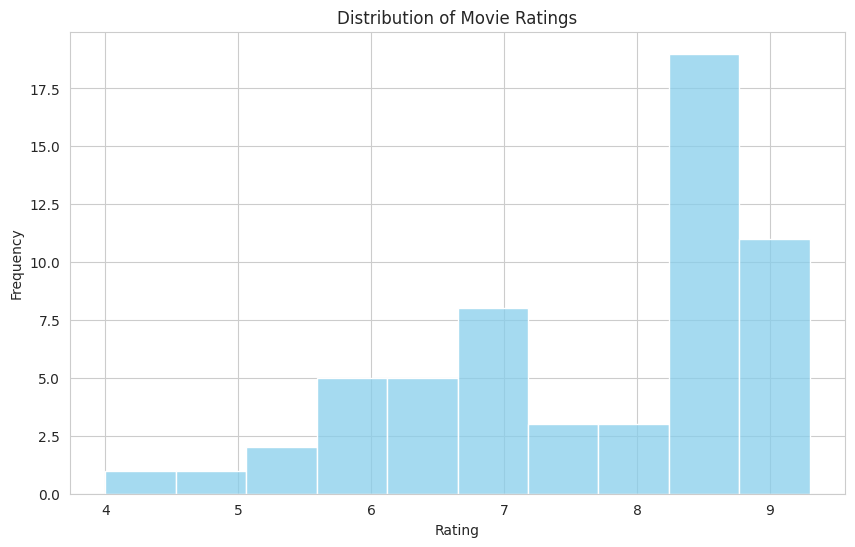

In [16]:

# Set the style for the plots
sns.set_style("whitegrid")

# 1. Distribution plot for rating
plt.figure(figsize=(10, 6))
sns.histplot(movies_df['Rating'], bins=10, kde=False, color='skyblue')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()


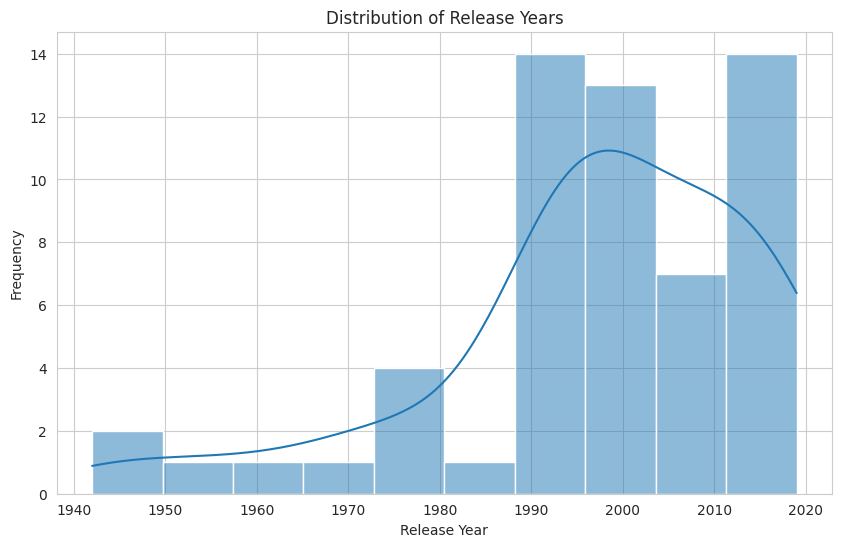

In [17]:
# 2. Released year distribution plot
plt.figure(figsize=(10, 6))
sns.histplot(movies_df['Release Year'], bins=10, kde=True)
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()



In [18]:
# split the genres
genres = [genre.strip() for sublist in movies_df['Genres'].str.split(',') for genre in sublist]

genre_counts = pd.Series(genres).value_counts()

In [ ]:
genre_counts

,count
Drama,39
Thriller,15
Adventure,14
Crime,13
Action,13
Comedy,12
Sci-Fi,10
Fantasy,9
Mystery,9
Horror,9


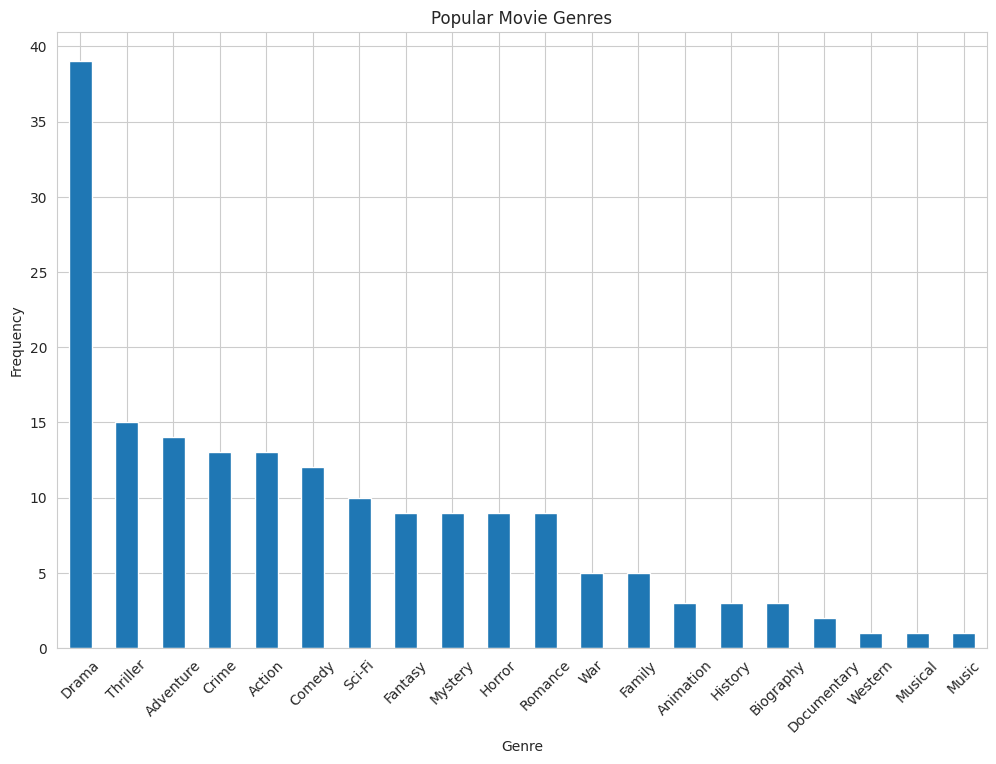

In [20]:
# Visualize the same.

plt.figure(figsize=(12, 8))
genre_counts.plot(kind='bar')
plt.title('Popular Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()



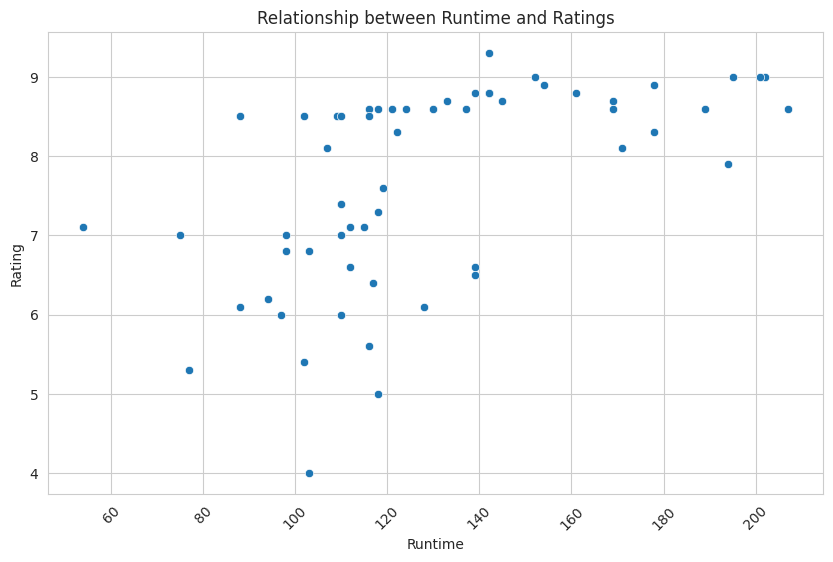

In [21]:
# relationship between rating and runtime
plt.figure(figsize=(10, 6))
sns.scatterplot(x='runtime', y='Rating', data=movies_df)
plt.title('Relationship between Runtime and Ratings')
plt.xlabel('Runtime')
plt.ylabel('Rating')
plt.xticks(rotation=45)  # Rotate the x-axis labels by 45 degrees
plt.show()

<Figure size 1000x600 with 0 Axes>

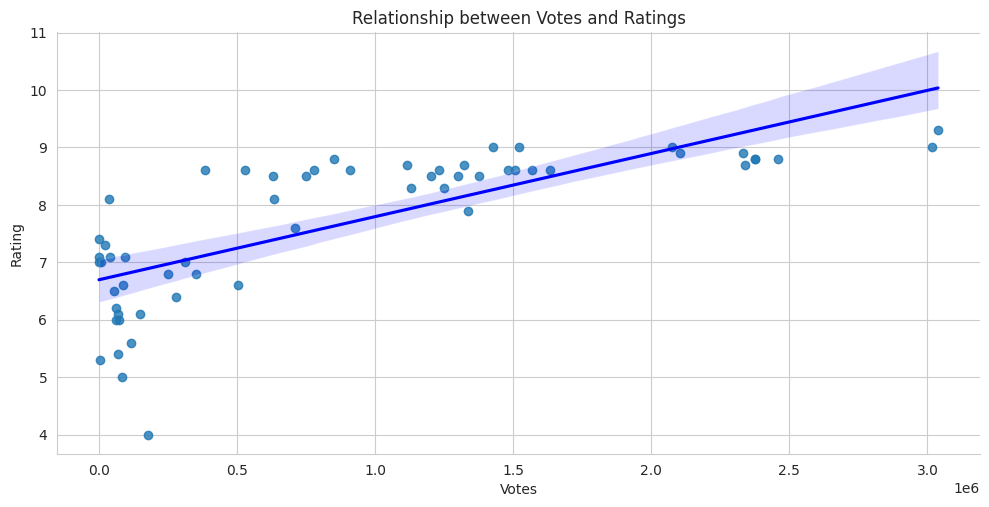

In [22]:
# 4. Relationship between votes and ratings
plt.figure(figsize=(10, 6))
# sns.scatterplot(x='votes', y='Rating', data=movies_df, color='orange')
sns.lmplot(x='votes', y='Rating', data=movies_df, aspect=2, line_kws={'color': 'blue'})
plt.title('Relationship between Votes and Ratings')
plt.xlabel('Votes')
plt.ylabel('Rating')
plt.show()

In [31]:


# Define the independent variable (votes) and the dependent variable (Rating)
X = movies_df[['votes']]
y = movies_df['Rating']

# Add a constant to the independent variable (X) for the intercept term
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Print the summary of the regression model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Rating   R-squared:                       0.566
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     72.98
Date:                Thu, 01 May 2025   Prob (F-statistic):           9.97e-12
Time:                        08:42:12   Log-Likelihood:                -71.209
No. Observations:                  58   AIC:                             146.4
Df Residuals:                      56   BIC:                             150.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.6951      0.159     42.116      0.0

In [32]:
X['predicted_rating'] = model.predict(X)
X['actual_rating'] = movies_df['Rating']
X

,const,votes,predicted_rating,actual_rating
0,1.0,3038384,10.034462,9.3
1,1.0,1426921,8.263375,9.0
2,1.0,3015148,10.008925,9.0
3,1.0,22955,6.720338,7.3
4,1.0,1519881,8.365543,9.0
5,1.0,2074466,8.975063,9.0
6,1.0,2330943,9.256945,8.9
7,1.0,2459675,9.398429,8.8
8,1.0,2104300,9.007852,8.9
9,1.0,2374870,9.305223,8.8
